Шаг 1: Загрузка данных и моделей

In [ ]:
pip install -r requirements.txt

In [16]:
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import json
import numpy as np

model1 = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
model2 = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Шаг 2: генерация эмбеддингов и поиск

In [17]:
with open('code_corpus.json', 'r', encoding='utf-8') as f:
    data_embedding_code_corpus = json.load(f)

embeddings1_code_corpus = []
embeddings2_code_corpus = []
text = None

for i in data_embedding_code_corpus:
    text = i['description']

    embeddings1_code_corpus.append(model1.encode(text))
    embeddings2_code_corpus.append(model2.encode(text))

with open('eval_questions.json', 'r', encoding='utf-8') as j:
    data_eval_questions = json.load(j)

embeddings1_eval_questions = []
embeddings2_eval_questions = []
count = 0
text = None

for u in data_eval_questions:
    if count >= 15: break
    count += 1
    text = u['query']

    embeddings1_eval_questions.append(model1.encode(text))
    embeddings2_eval_questions.append(model2.encode(text))

np_code_corpus1 = np.array(embeddings1_code_corpus)
np_code_corpus2 = np.array(embeddings2_code_corpus)

np_eval_questions1 = np.array(embeddings1_eval_questions)
np_eval_questions2 = np.array(embeddings2_eval_questions)

total_cos_similarity1 = []
total_cos_similarity2 = []

for h in np_eval_questions1:
    cos_similarity1 = []
    for r in np_code_corpus1:
        cos_similarity1.append(util.cos_sim(h, r).item())
    total_cos_similarity1.append(cos_similarity1)

for s in np_eval_questions2:
    cos_similarity2 = []
    for d in np_code_corpus2:
        cos_similarity2.append(util.cos_sim(s, d).item())
    total_cos_similarity2.append(cos_similarity2)

Шаг 3: Метрика и визуализация

In [18]:
np_total_cos_similarity1 = np.array(total_cos_similarity1)
np_total_cos_similarity2 = np.array(total_cos_similarity2)

top3_output_index_1 = np_total_cos_similarity1.argsort(axis=1)[:,::-1][:,:3]
top3_output_index_2 = np_total_cos_similarity2.argsort(axis=1)[:,::-1][:,:3]

all_correct1 = []
all_correct2 = []

precision_3_1 = 0.0
precision_3_2 = 0.0

for i in range(len(embeddings1_eval_questions)):
    correct_list = False
    for j in top3_output_index_1[i]:
        if data_embedding_code_corpus[j]['id'] == data_eval_questions[i]['correct_chunk_id']:
            correct_list = True
            break
    all_correct1.append(correct_list)

for i in range(len(embeddings2_eval_questions)):
    correct_list = False
    for j in top3_output_index_2[i]:
        if data_embedding_code_corpus[j]['id'] == data_eval_questions[i]['correct_chunk_id']:
            correct_list = True
            break
    all_correct2.append(correct_list)

precision_3_1 = all_correct1.count(True) / len(all_correct1)
precision_3_2 = all_correct2.count(True) / len(all_correct2)            # Лучшей моделью оказалась модель №2

print(f'paraphrase-multilingual-MiniLM-L12-v2 precision: {round(precision_3_1, 3)}\nnparaphrase-multilingual-mpnet-base-v2 precision: {round(precision_3_2, 3)}')

paraphrase-multilingual-MiniLM-L12-v2 precision: 0.733
nparaphrase-multilingual-mpnet-base-v2 precision: 0.667


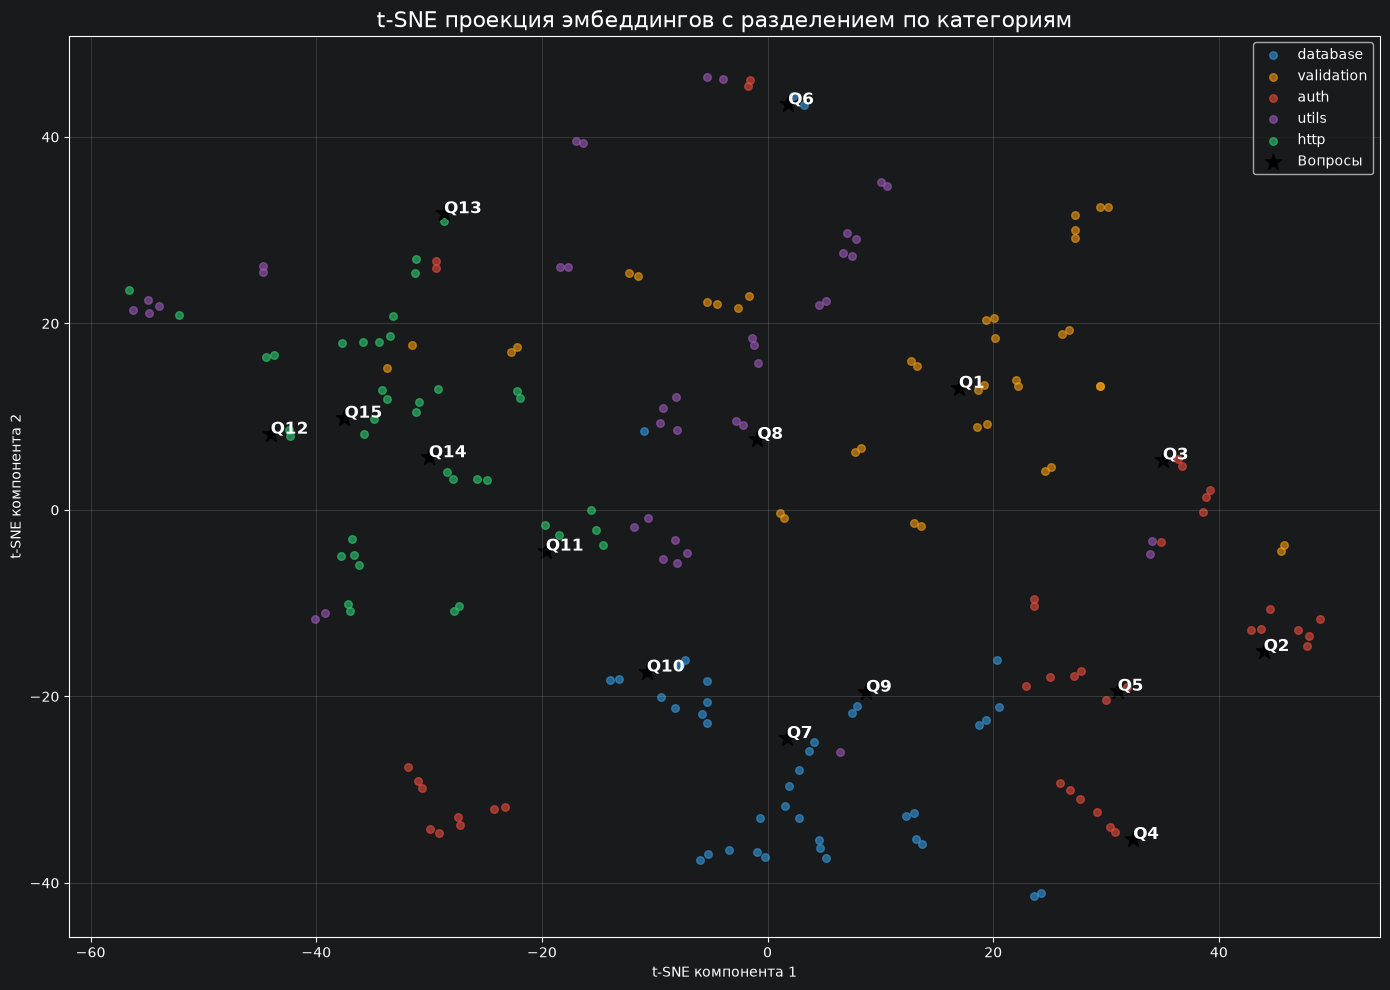

In [19]:
all_embeddings = np.vstack([np_code_corpus1, np_eval_questions1])

tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords = tsne.fit_transform(all_embeddings)

code_coords = coords[:200]
question_coords = coords[200:]

with open('categories.json', 'r', encoding='utf-8') as f:
    categories_data = json.load(f)
color_map = {cat['key']: cat['color'] for cat in categories_data['categories']}

code_categories = [item['category'] for item in data_embedding_code_corpus]

plt.figure(figsize=(14, 10))

unique_categories = list(set(code_categories))
for category in unique_categories:
    idxs = [i for i, cat in enumerate(code_categories) if cat == category]
    plt.scatter(
        code_coords[idxs, 0],
        code_coords[idxs, 1],
        alpha=0.6,
        s=30,
        c=color_map.get(category, 'gray'),
        label=category
    )

plt.scatter(
    question_coords[:, 0],
    question_coords[:, 1],
    alpha=0.9,
    s=150,
    c='black',
    marker='*',
    label='Вопросы'
)

for i, (x, y) in enumerate(question_coords):
    plt.annotate(f'Q{i+1}', (x, y), fontsize=12, fontweight='bold')

plt.title('t-SNE проекция эмбеддингов с разделением по категориям', fontsize=16)
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### ВЫВОД
Лучшей моделью оказалась paraphrase-multilingual-mpnet-base-v2 с Precision@3 = 66.67%.
На графике t-SNE видно, что фрагменты кода образуют кластеры по категориям, вопросы попадают в соответствующие кластеры. Это подтверждает, что модель подходит для использования в семантическом поиске.